In [1]:
import websockets
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Arquivos esperados

Antes de rodar o serviço no robô, coloque este arquivo diretamente dentro da pasta `Localização`:

- `camera_calibration_results.npz`: salvo pelo notebook `camera_calibration.ipynb`.

A máscara é construída automaticamente no serviço a partir do mapa de reprojeção, mantendo apenas os pixels que apontam para dentro da imagem original e aplicando uma erosão para afastar as bordas.

In [2]:
from pathlib import Path

LOCALIZACAO_DIR = Path.cwd().parent
CALIB_PATH = LOCALIZACAO_DIR / 'camera_calibration_results.npz'

print('CALIB_PATH:', CALIB_PATH)
print('existe:', CALIB_PATH.exists())

CALIB_PATH: /home/grupoa/Localizacao/camera_calibration_results.npz
existe: True


## Teste direto do detector

Rode esta célula no robô antes de iniciar o servidor. Ela inicializa o mesmo detector usado pelo serviço, captura um quadro e confere se a saída tem o formato esperado.

In [3]:
from picamera2 import Picamera2
import os

from servico_circulos import Detector, CAMERA_SIZE

Picamera2.set_logging(Picamera2.ERROR)
os.environ['LIBCAMERA_LOG_LEVELS'] = '3'

with Picamera2(tuning=os.environ.get('LIBCAMERA_RPI_TUNING_FILE', None)) as camera:
    camera.configure(camera.create_still_configuration(main={'size': CAMERA_SIZE}))
    camera.start()
    detector = Detector(9, 18, camera)
    coordenadas, timestamp = detector.detecta()
    camera.stop()

print('timestamp:', timestamp)
print('coordenadas:', coordenadas)
assert isinstance(coordenadas, list)
for p in coordenadas:
    assert len(p) == 2

ERROR is deprecated. Returning `import logging; logging.ERROR` instead


timestamp: 1781880744421553408g: 0.18593239784240723
coordenadas: [[60.25, 9.25], [162.25, 29.75], [260.75, 50.75], [284.25, -126.25], [270.75, -39.75], [367.75, -15.75], [358.25, 72.25], [299.75, -268.75], [197.75, -222.25], [286.25, -206.25]]


## Teste pelo websocket

Em um terminal do robô, inicie o serviço com:

```bash
python3 servico_circulos.py -p 8086
```

In [10]:
endereco_robo="localhost" # Substitua pelo endereço do robô se necessário
porta_servico="8086"
async with websockets.connect(f"ws://{endereco_robo}:{porta_servico}/wsctrl") as websocket:
    await websocket.send("ack")
    res = json.loads(await  websocket.recv())

assert 'timestamp' in res
assert 'coordenadas' in res
print(res)

{'timestamp': 1781705751940050432, 'coordenadas': [[230.75, 156.75], [210.25, 38.75], [190.25, -66.75], [261.75, -169.75], [313.25, 29.25]]}


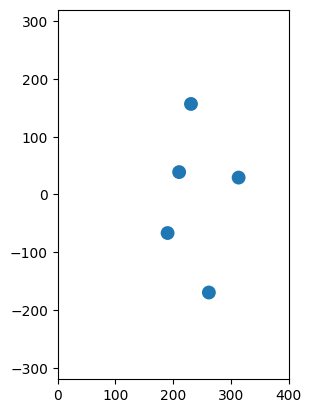

In [11]:
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.set_xlim(0,400)
ax.set_ylim(-320,320)
for x, y in res["coordenadas"]:
    c = mpatches.Circle((x,y), radius=12)
    ax.add_patch(c)

### 8.4 - Filtro de partículas 

In [30]:
import cv2
import numpy as np

# k-d tree do FLANN (algorithm=1). O mapa com as coordenadas dos circulos do
# ambiente e' indexado no matcher; calc_w usa knnMatch para achar, para cada
# observacao, os pontos mais proximos no mapa (passo 2 da secao 8.4.1).
FLANN_INDEX_KDTREE = 1


def cria_matcher(mapa):
    """Cria um cv2.FlannBasedMatcher ja carregado com o mapa do ambiente.

    `mapa` e' um array (M, 2) com as coordenadas globais (mm) de cada circulo
    conhecido do cenario.
    """
    mapa = np.asarray(mapa, dtype=np.float32).reshape(-1, 2)
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    matcher = cv2.FlannBasedMatcher(index_params, search_params)
    matcher.add([mapa])
    matcher.train()
    return matcher


def calc_w(estado, obs, knnmatcher, sigma2, alpha_r2):
    """Peso (verossimilhanca) de um estado do robô dado o conjunto de circulos
    observados, segundo o modelo sensorial da secao 8.4 (equacao 8.8).

    estado     : (3,)  -> (x, y, theta) global, em mm e rad.
    obs        : (N,2) -> coordenadas locais (mm) do centro de cada circulo.
    knnmatcher : cv2.FlannBasedMatcher carregado com o mapa (ver cria_matcher).
    sigma2     : sigma_c^2 da equacao 8.7 (constante).
    alpha_r2   : alpha (=> coeficiente de r^2) da equacao 8.7 (constante).
    """
    obs = np.asarray(obs, dtype=np.float32).reshape(-1, 2)
    n_obs = obs.shape[0]
    if n_obs == 0:
        return 0.0

    rx, ry, rth = float(estado[0]), float(estado[1]), float(estado[2])
    ct, st = np.cos(rth), np.sin(rth)

    # Passo 1: observacao (sistema local) -> coordenadas globais (c_x, c_y).
    #   c_x = r_x + o_x cos(theta) - o_y sin(theta)
    #   c_y = r_y + o_y cos(theta) + o_x sin(theta)
    c = np.empty((n_obs, 2), dtype=np.float64)
    c[:, 0] = rx + obs[:, 0] * ct - obs[:, 1] * st
    c[:, 1] = ry + obs[:, 0] * st + obs[:, 1] * ct

    # Mapa com as coordenadas dos circulos (recuperado do proprio matcher).
    mapa = np.asarray(knnmatcher.getTrainDescriptors()[0], dtype=np.float64)
    n_map = mapa.shape[0]
    k = min(n_obs, n_map)

    # Incerteza por observacao (eq. 8.7): sigma(r)^2 = sigma_c^2 + alpha * r^2,
    # com r^2 = o_x^2 + o_y^2 (objetos mais distantes -> mais incertos).
    r2 = obs[:, 0] ** 2 + obs[:, 1] ** 2
    sigma_r2 = sigma2 + alpha_r2 * r2

    # Passo 2: os k pontos do mapa mais proximos de cada observacao.
    matches = knnmatcher.knnMatch(c.astype(np.float32), k=k)

    # Passo 3: distancia ao quadrado normalizada pela incerteza, para cada
    # associacao candidata (observacao i, ponto j):
    #   d2_ij / (2 * sigma(r_i)^2)
    INF = np.inf
    cost = np.full((n_obs, n_map), INF)
    for i, candidatos in enumerate(matches):
        for m in candidatos:
            j = m.trainIdx
            d2 = (c[i, 0] - mapa[j, 0]) ** 2 + (c[i, 1] - mapa[j, 1]) ** 2
            cost[i, j] = d2 / (2.0 * sigma_r2[i])

    # Passo 4: associacao gulosa de maxima verossimilhanca. Enquanto houver
    # observacao não associada: associe a observacao de MAIOR distancia minima
    # ao seu ponto mais proximo ainda livre e retire esse ponto dos demais.
    total = 0.0
    obs_livre = np.ones(n_obs, dtype=bool)
    pt_livre = np.ones(n_map, dtype=bool)
    for _ in range(k):
        melhor_pt = -np.ones(n_obs, dtype=int)
        melhor_custo = np.full(n_obs, INF)
        for i in range(n_obs):
            if not obs_livre[i]:
                continue
            linha = np.where(pt_livre, cost[i], INF)  # so' pontos ainda livres
            j = int(np.argmin(linha))
            if np.isfinite(linha[j]):
                melhor_custo[i] = linha[j]
                melhor_pt[i] = j
        # observacao com a MAIOR distancia minima entre as ainda livres
        candidato = melhor_custo.copy()
        candidato[~obs_livre] = -INF
        candidato[melhor_pt < 0] = -INF
        i_sel = int(np.argmax(candidato))
        if candidato[i_sel] == -INF:
            break  # não há mais associacoes possiveis
        j_sel = melhor_pt[i_sel]
        total += cost[i_sel, j_sel]
        obs_livre[i_sel] = False
        pt_livre[j_sel] = False

    # Peso total do estado (eq. 8.8). A normalizacao e' desnecessaria: o filtro
    # usa apenas valores proporcionais a probabilidade.
    return float(np.exp(-total))


#### Filtro de partículas (Localização de Monte Carlo)

Parametros do problema (seção 8.4):

- **20000** partículas iniciais, distribuição uniforme: `x, y` em [-200, 200] mm e `theta` em [0, 2*pi].
- `sigma2_c = 20` (aprox. 1/3 do raio do círculo ao quadrado + 2 px2) e `alpha = 0.012`.
- Pesos calculados por `calc_w` (eq. 8.8) e **reamostragem** de **10000** partículas com `numpy.random.choice`.

As **observações** (`obs`) são as coordenadas locais, em mm, dos centros dos círculos detectados pelo serviço da seção 8.3. Inicie o serviço no robô e aponte a câmera para a folhá A4 impressa do cenário (`drawing_1.pdf`, `drawing_s.pdf` ou `drawing_3.pdf`); cada célula de cenário lê um quadro pelo websocket. Veja `README_filtro_particulas.md` para o passo a passo no robô.


In [ ]:
# Constantes do filtro (secao 8.4)
N_PART = 20000          # populacao inicial
N_RESAMPLE = 10000      # populacao reamostrada
SIGMA2 = 20.0           # sigma_c^2  (eq. 8.7)
ALPHA_R2 = 0.01 ** 2    # alpha      (eq. 8.7)

ENDERECO_ROBO = "localhost"   # endereço do robô, se o notebook não roda nele
PORTA_SERVICO = "8086"


async def obs_do_servico():
    """Le um quadro do servico de detecção de circulos (secao 8.3) e devolve as
    coordenadas locais (mm) dos centros detectados como array (N, 2)."""
    uri = f"ws://{ENDERECO_ROBO}:{PORTA_SERVICO}/wsctrl"
    async with websockets.connect(uri) as websocket:
        await websocket.send("ack")
        res = json.loads(await websocket.recv())
    return np.asarray(res["coordenadas"], dtype=float).reshape(-1, 2)


def localiza(mapa, obs, n_part=N_PART, n_resample=N_RESAMPLE,
             sigma2=SIGMA2, alpha_r2=ALPHA_R2, rng=None):
    """Roda um passo de Localizacao de Monte Carlo para o 'robô sequestrado'.

    Inicializa `n_part` particulas uniformes, calcula os pesos com calc_w e
    reamostra `n_resample` particulas. Retorna (particulas_reamostradas, eta).
    """
    if rng is None:
        rng = np.random.default_rng()
    matcher = cria_matcher(mapa)

    # Populacao inicial uniforme (passo de previsão do robô sequestrado).
    part = np.empty((n_part, 3))
    part[:, 0] = rng.uniform(-200, 200, n_part)     # x
    part[:, 1] = rng.uniform(-200, 200, n_part)     # y
    part[:, 2] = rng.uniform(0, 2 * np.pi, n_part)  # theta

    # Passo de correção: peso de cada particula.
    obs = np.asarray(obs, dtype=float).reshape(-1, 2)
    w = np.array([calc_w(part[i], obs, matcher, sigma2, alpha_r2)
                  for i in range(n_part)])
    eta = w.sum()
    if eta == 0.0:
        # eta ~ 0 sinaliza o "sequestro": nenhuma hipotese compativel.
        print("AVISO: eta = 0 (possivel sequestro / sem observacoes validas).")
        return part[:0], eta

    # Reamostragem proporcional aos pesos.
    idx = rng.choice(n_part, size=n_resample, p=w / eta)
    return part[idx], eta


def plota_resultado(mapa, part, ax, titulo):
    mapa = np.asarray(mapa, dtype=float).reshape(-1, 2)
    ax.set_aspect("equal")
    ax.set_xlim(-200, 200)
    ax.set_ylim(-200, 200)
    if len(part):
        ax.scatter(part[:, 0], part[:, 1], s=2, c="k", alpha=0.05,
                   label="particulas")
    ax.scatter(mapa[:, 0], mapa[:, 1], s=60, c="tab:blue", zorder=3,
               label="mapa")
    ax.set_title(titulo)
    ax.legend(loc="upper right", fontsize=8)


obs (local, mm): [[188.75   5.75]]
eta = 17.073328468852054


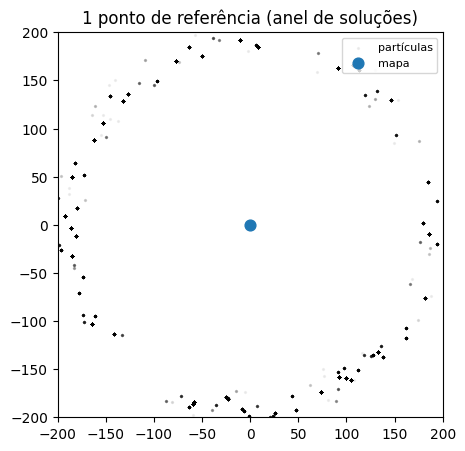

In [14]:
# --- Cenario com 1 ponto de referencia (Figuras 8.7 / 8.10) ---
# Aponte a camera do robô para a folhá drawing_1.pdf.
mapa_1 = np.array([[0.0, 0.0]])

obs = await obs_do_servico()
print("obs (local, mm):", obs)

part_1, eta_1 = localiza(mapa_1, obs)
print("eta =", eta_1)

fig, ax = plt.subplots(figsize=(5, 5))
plota_resultado(mapa_1, part_1, ax,
                "1 ponto de referencia (anel de solucoes)")
plt.show()


obs (local, mm): [[202.25  45.75]
 [191.75 -66.75]]
eta = 0.10649925998772171


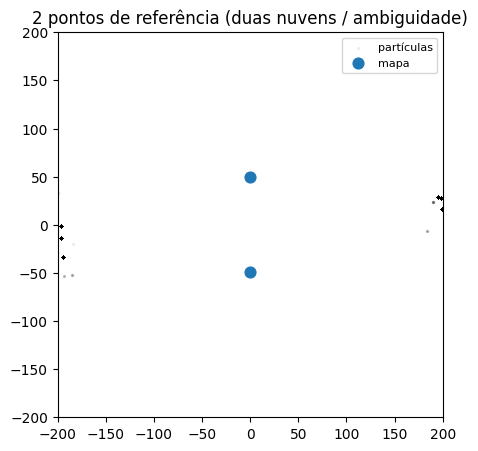

In [15]:
# --- Cenario com 2 pontos de referencia (Figuras 8.8 / 8.11) ---
# Aponte a camera do robô para a folhá drawing_s.pdf.
mapa_2 = np.array([[0.0, 297 / 6], [0.0, -297 / 6]])

obs = await obs_do_servico()
print("obs (local, mm):", obs)

part_2, eta_2 = localiza(mapa_2, obs)
print("eta =", eta_2)

fig, ax = plt.subplots(figsize=(5, 5))
plota_resultado(mapa_2, part_2, ax,
                "2 pontos de referencia (duas nuvens / ambiguidade)")
plt.show()


obs (local, mm): [[ 131.75    2.75]
 [ 249.25  110.75]
 [ 233.75 -102.75]]
eta = 8.408357717512745e-05


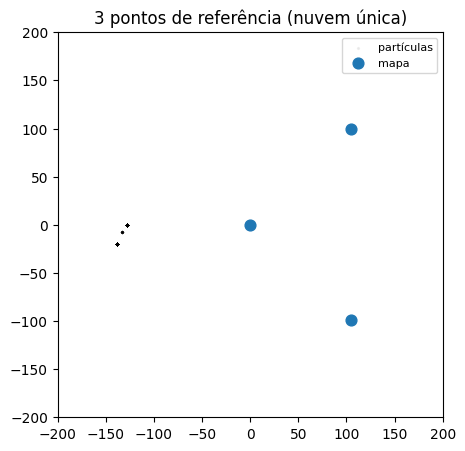

In [16]:
# --- Cenario com 3 pontos de referencia (Figuras 8.9 / 8.12) ---
# Aponte a camera do robô para a folhá drawing_3.pdf.
mapa_3 = np.array([[0.0, 0.0], [105.0, 99.0], [105.0, -99.0]])

obs = await obs_do_servico()
print("obs (local, mm):", obs)

part_3, eta_3 = localiza(mapa_3, obs)
print("eta =", eta_3)

fig, ax = plt.subplots(figsize=(5, 5))
plota_resultado(mapa_3, part_3, ax,
                "3 pontos de referencia (nuvem unica)")
plt.show()


## 8.5 - Modelo cinematico de segunda ordem

Nesta seção o estado de cada partícula passa a guardar também velocidade translacional e a velocidade angular anterior:

$$x_i = [x, y, \theta, v_x, v_y, \omega]^T$$

A ação medida pela IMU e:

$$u_i = [a_{x'}, a_{y'}, \omega_i]^T$$

As acelerações `ax'` e `ay'` são locais ao robô. O modelo abaixo transforma estas acelerações para o referencial global, integra posição e velocidade, e trata separadamente o caso em que a velocidade angular média e muito pequena para evitar divisões numericamente ruins.

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def novo_estado(estado, acao, deltat, beta, sigmax, sigmay, sigmaw, epsilon):
    """Sorteia uma nova particula pelo modelo cinematico da secao 8.5.

    estado = [x, y, theta, vx, vy, omega_anterior]
    acao   = [ax_linha, ay_linha, omega_medido]

    Posicoes em mm, velocidades em mm/s, aceleracoes em mm/s^2,
    angulos em rad e tempo em s.
    """
    x_ant, y_ant, theta_ant, vx_ant, vy_ant, omega_ant = np.asarray(estado, dtype=float)
    ax_l, ay_l, omega_i = np.asarray(acao, dtype=float)

    # 1. Perturba as leituras da IMU.
    ax_l = ax_l + np.random.normal(0.0, sigmax)
    ay_l = ay_l + np.random.normal(0.0, sigmay)
    omega_i = omega_i + np.random.normal(0.0, sigmaw)

    # 2 e 3. Velocidade angular média e nova orientacao.
    omega_m = (omega_ant + omega_i) / 2.0
    theta_i = theta_ant + omega_m * deltat

    # 4. Aceleracao global no fim do intervalo, eqs. (8.28), (8.29).
    ax_i = ax_l * np.cos(theta_i) - ay_l * np.sin(theta_i)
    ay_i = ay_l * np.cos(theta_i) + ax_l * np.sin(theta_i)

    if abs(omega_m) < epsilon:
        # Caso limite das eqs. (8.34), (8.35), (8.44), (8.45).
        vx_i = vx_ant + ax_i * deltat
        vy_i = vy_ant + ay_i * deltat
        x_i = x_ant + vx_ant * deltat + ax_i * deltat**2 / 2.0
        y_i = y_ant + vy_ant * deltat + ay_i * deltat**2 / 2.0
    else:
        # Aceleracao global no inicio do intervalo, eqs. (8.30), (8.31).
        ax_ast = ax_l * np.cos(theta_ant) - ay_l * np.sin(theta_ant)
        ay_ast = ay_l * np.cos(theta_ant) + ax_l * np.sin(theta_ant)

        # Eqs. (8.46), (8.47).
        dx_i = (ax_i - ax_ast) / omega_m
        dy_i = (ay_i - ay_ast) / omega_m

        # Eqs. (8.48), (8.49), (8.50), (8.51).
        vx_i = vx_ant + dy_i
        vy_i = vy_ant - dx_i
        x_i = x_ant + (vx_ant - ay_ast / omega_m) * deltat - dx_i / omega_m
        y_i = y_ant + (vy_ant + ax_ast / omega_m) * deltat - dy_i / omega_m

    # 6. Ruido de modelo diretamente em posicao.
    x_i = x_i + np.random.normal(0.0, beta * deltat)
    y_i = y_i + np.random.normal(0.0, beta * deltat)

    return np.array([x_i, y_i, theta_i, vx_i, vy_i, omega_i], dtype=float)


### Conferencia dos exemplos da tarefa

Para conferir a implementação, zeramos todos os ruídos. Assim o sorteio vira deterministico e os tres exemplos da apostila devem bater exatamente, dentro de erro numérico.

In [5]:
EPS = 1e-4

casos = [
    ('1) aceleracao para frente sem rotacao',
     [0, 0, 0, 0, 0, 0], [1, 0, 0], 1,
     [1/2, 0, 0, 1, 0, 0]),
    ('2) aceleracao lateral com theta = pi/2',
     [0, 0, np.pi/2, 0, 0, 0], [0, 1, 0], 1,
     [-1/2, 0, np.pi/2, -1, 0, 0]),
    ('3) rotacao com velocidade inicial',
     [0, 0, 0, 1, 0, 0], [0, 1, 2], np.pi/2,
     [1, 1, np.pi/2, 0, 1, 2]),
]

for nome, estado, acao, deltat, esperado in casos:
    obtido = novo_estado(
        estado, acao, deltat,
        beta=0, sigmax=0, sigmay=0, sigmaw=0, epsilon=EPS,
    )
    esperado = np.asarray(esperado, dtype=float)
    print(nome)
    print('  obtido  :', np.round(obtido, 6))
    print('  esperado:', np.round(esperado, 6))
    assert np.allclose(obtido, esperado, atol=1e-9)

print('Todos os exemplos da tarefa conferem.')


1) aceleracao para frente sem rotacao
  obtido  : [0.5 0.  0.  1.  0.  0. ]
  esperado: [0.5 0.  0.  1.  0.  0. ]
2) aceleracao lateral com theta = pi/2
  obtido  : [-0.5       0.        1.570796 -1.        0.        0.      ]
  esperado: [-0.5       0.        1.570796 -1.        0.        0.      ]
3) rotacao com velocidade inicial
  obtido  : [1.       1.       1.570796 0.       1.       2.      ]
  esperado: [1.       1.       1.570796 0.       1.       2.      ]
Todos os exemplos da tarefa conferem.


### Reproducao da Figura 8.14

A apostila usa 20 partículas. O estado inicial e:

$$x_0=-10,\quad y_0=0,\quad \theta_0=\pi/2,\quad v_{x0}=0,\quad v_{y0}=5\pi/4,\quad \omega_0=-\pi/8$$

Em todos os passos, a IMU mede:

$$a_{x'}=0,\quad a_{y'}=-5\pi^2/32,\quad \omega=-\pi/8$$

As incertezas são `beta = 0`, `sigmax = sigmay = 1/4`, `sigmaw = 1/64` e `epsilon = 0.0001`. A semente fixa abaixo deixa a figura reprodutível para o relatório.

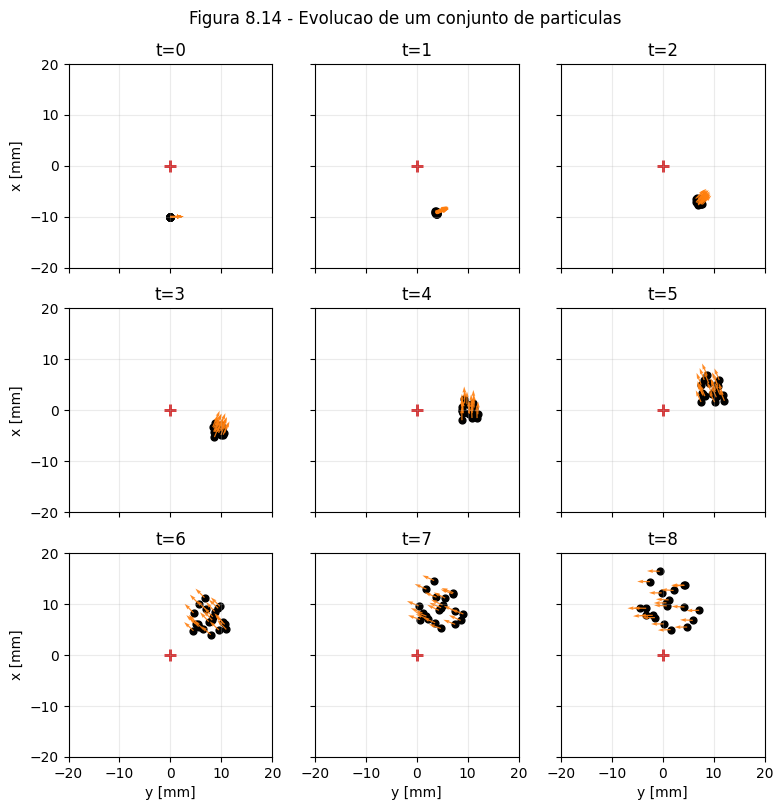

In [6]:
np.random.seed(3502)

N_PARTICULAS = 20
N_PASSOS = 8
DELTAT = 1.0

estado_inicial = np.array([-10.0, 0.0, np.pi/2, 0.0, 5*np.pi/4, -np.pi/8])
acao_constante = np.array([0.0, -5*np.pi**2/32, -np.pi/8])

BETA = 0.0
SIGMAX = 1/4
SIGMAY = 1/4
SIGMAW = 1/64
EPSILON = 1e-4

historico = [np.repeat(estado_inicial[None, :], N_PARTICULAS, axis=0)]

for _ in range(N_PASSOS):
    anterior = historico[-1]
    proximo = np.array([
        novo_estado(p, acao_constante, DELTAT, BETA, SIGMAX, SIGMAY, SIGMAW, EPSILON)
        for p in anterior
    ])
    historico.append(proximo)

fig, axes = plt.subplots(3, 3, figsize=(9, 9), sharex=True, sharey=True)

for t, ax in enumerate(axes.flat):
    part = historico[t]
    # Convencao Norte-Leste-Baixo: x no eixo vertical, y no horizontal.
    ax.scatter(part[:, 1], part[:, 0], s=24, color='black')

    # Orientacao da particula: theta e medido a partir do eixo global x.
    # Como o grafico usa horizontal=y e vertical=x, a seta fica
    # (dy, dx) = (sin(theta), cos(theta)).
    comprimento = 2.5
    ax.quiver(
        part[:, 1], part[:, 0],
        comprimento * np.sin(part[:, 2]),
        comprimento * np.cos(part[:, 2]),
        angles='xy', scale_units='xy', scale=1,
        width=0.006, color='tab:orange', alpha=0.9,
    )

    ax.scatter([0], [0], marker='+', s=80, color='tab:red', linewidths=2)
    ax.set_title(f't={t}')
    ax.set_xlim(-20, 20)
    ax.set_ylim(-20, 20)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)

for ax in axes[-1, :]:
    ax.set_xlabel('y [mm]')
for ax in axes[:, 0]:
    ax.set_ylabel('x [mm]')

fig.suptitle('Figura 8.14 - Evolucao de um conjunto de particulas', y=0.94)
plt.show()


### Leitura do resultado

As partículas partem da mesma condição inicial e se espalham com o tempo. O movimento médio forma um arco ao redor da origem porque a velocidade angular e aproximadamente constante e a aceleração lateral local atua como aceleração centripeta. Como `beta = 0`, a dispersão vem das perturbacoes independentes nas leituras `ax'`, `ay'` e `omega`, não de ruido somado diretamente a `x` e `y`.

## 8.6 - Juntando tudo: Localização de Monte Carlo offline

A versão desta seção é offline: primeiro coletamos, em um arquivo CSV, leituras assíncronas da câmera e da IMU; depois processamos esse arquivo ordenando as amostras pelo timestamp de captura. Isso evita o problema de latência do vídeo: a câmera pode demorar para entregar uma detecção, mas o timestamp ainda corresponde ao momento em que a imagem foi capturada.

A sequência implementada aqui segue a apostila:

1. Coletar dados de círculos e IMU.
2. Ordenar tudo por timestamp.
3. Calibrar o viés da IMU com o robô parado.
4. Resolver a localização inicial como problema do robô sequestrado.
5. Reconstruir a trajetória alternando previsão por IMU e correção por câmera.

### Ordem de execução no Raspberry Pi

Execute estes comandos no robô, na ordem. A ideia é manter o fluxo o mais próximo possível da apostila: o programa de coleta tem `endereco_robo` definido no início do arquivo, então altere essa variável ali se o coletor não estiver rodando no próprio robô.

1. Entre na pasta do serviço de círculos:

```bash
cd ~/Mobile_Robotics/Localizacao/pmr3502-deteccao-circulos-main
```

2. Garanta que a calibração da câmera esteja no local esperado pelo `servico_circulos.py`:

```bash
cp ~/Mobile_Robotics/pmr3502-camera-calibration/camera_calibration_results.npz ../camera_calibration_results.npz
```

3. Reduza a taxa de amostragem da IMU para 20 Hz, como na apostila. Execute antes de ativar o serviço que publica a IMU:

```bash
echo 20 | sudo tee /sys/bus/iio/devices/iio:device0/sampling_frequency
```

Se o dispositivo tiver outro número (`iio:device1`, por exemplo), descubra com:

```bash
ls /sys/bus/iio/devices/
cat /sys/bus/iio/devices/iio:device*/name
```

4. Em um terminal, inicie o serviço de detecção de círculos da seção 8.3:

```bash
python3 servico_circulos.py -p 8086
```

Observe no terminal desse serviço os valores `FPS` e `lag`. Eles serão usados abaixo para comparar com a coleta offline.

5. Em outro terminal, inicie o serviço da IMU do capítulo 3. Use o comando da seção 3.3.1 e especifique o nome de rede do robô com `-e`, como indicado na apostila. A seção 8.6 assume que esse serviço publica pacotes binários de 32 bytes na porta `1234`.

6. Antes de coletar, abra `coleta_localizacao.py` e ajuste, se necessário:

```python
endereco_robo = "localhost"  # troque para o IP/nome do robô se rodar fora dele
porta_servico_circulos = "8086"
porta_servico_imu = 1234
```

7. Em um terceiro terminal, colete os dados. Primeiro faça uma coleta curta de pelo menos 30 linhas para responder à pergunta de sincronia. Depois faça a coleta longa: mantenhá o robô parado por pelo menos 30 segundos no início, conduza uma trajetória lenta e reconhecível, e termine parado.

```bash
python3 coleta_localizacao.py > coleta_localizacao.csv
```

O programa roda até ser interrompido. Pare com `Ctrl+C`. Copie `coleta_localizacao.csv` para esta pasta e rode as células abaixo.

### Leitura e diagnóstico de sincronia

Cada linha da coleta tem o formato:

- `timestamp,c,x1,y1,x2,y2,...` para câmera;
- `timestamp,i,ax,ay,az,wx,wy,wz` para IMU.

O primeiro campo é o marco temporal da coleta, em nanossegundos. O segundo campo é `i` para IMU ou `c` para câmera. Como o processamento de vídeo atrasa a entrega da detecção, uma linha de câmera pode chegar depois de uma linha de IMU, mas trazer um timestamp menor.

A pergunta da apostila é respondida nesta etapa:

- colete ao menos 30 amostras;
- calcule o decréscimo médio do timestamp na transição IMU -> câmera;
- compare esse valor com o `lag` mostrado pelo `servico_circulos.py`;
- calcule, em média, quantas amostras de IMU aparecem para cada amostra da câmera;
- compare a razão medida com `20 / FPS`, pois a IMU foi configurada para 20 Hz.

In [17]:
import csv
import numpy as np
from dataclasses import dataclass
from pathlib import Path
import matplotlib.pyplot as plt


@dataclass
class IMUData:
    t: int
    a: np.ndarray
    w: np.ndarray


@dataclass
class CameraData:
    t: int
    c: np.ndarray


def data_from_row(row):
    if len(row) < 2:
        raise ValueError(f'Linha mal formatada (menos de 2 colunas): {row}')
    
    tipo = row[1]
    if tipo == 'i':
        if len(row) < 8:
            raise ValueError(f'Linha IMU esperava 8+ colunas, obteve {len(row)}')
        return IMUData(
            t=int(float(row[0])),
            a=np.asarray(row[2:5], dtype=np.float32),
            w=np.asarray(row[5:8], dtype=np.float32),
        )
    if tipo == 'c':
        if len(row) < 3:
            raise ValueError(f'Linha câmera esperava 3+ colunas, obteve {len(row)}')
        coord = np.asarray(row[3:], dtype=np.float32)
        if len(coord) % 2 != 0:
            raise ValueError(f'Câmera: esperado número par de valores, obteve {len(coord)}')
        return CameraData(t=int(float(row[0])), c=coord.reshape((-1, 2)))
    raise ValueError(f'Tipo de linha desconhecido: {tipo!r}')

def le_coleta_csv(caminho):
    """Le a coleta descartando linhas corrompidas (timestamp <= 0).

    O servico de IMU pode emitir linhas espurias "0,i,0,0,0,0,0,0" (timestamp 0
    e leitura nula) quando ainda nao esta transmitindo de fato. Como o
    processamento ordena tudo por timestamp, essas linhas iriam para o inicio da
    sequencia e contaminariam a calibracao do vies da IMU (que usa as 500
    primeiras leituras), zerando o vies e deixando a gravidade sem compensacao.
    Por isso elas sao removidas aqui.
    """
    leituras = []
    descartadas = 0
    with open(caminho, newline='') as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue
            dado = data_from_row(row)
            if dado.t <= 0:
                descartadas += 1
                continue
            leituras.append(dado)
    if descartadas:
        print(f'le_coleta_csv: {descartadas} linhas com timestamp <= 0 '
              f'descartadas (IMU espuria); {len(leituras)} leituras validas.')
    return leituras


def diagnostica_sincronia(leituras_na_ordem_de_recebimento,
                          lag_servico_ms=None,
                          fps_servico=None,
                          frequencia_imu_hz=20.0):
    quedas_camera = []
    transicoes_imu_camera = 0
    n_imu = 0
    n_camera = 0
    anterior = None

    for leitura in leituras_na_ordem_de_recebimento:
        if isinstance(leitura, IMUData):
            n_imu += 1
        else:
            n_camera += 1

        if isinstance(anterior, IMUData) and isinstance(leitura, CameraData):
            transicoes_imu_camera += 1
            dt = leitura.t - anterior.t
            if dt < 0:
                quedas_camera.append(-dt)

        anterior = leitura

    total = n_imu + n_camera
    duracao_s = None
    fps_camera_medido = None
    if len(leituras_na_ordem_de_recebimento) >= 2:
        t0 = leituras_na_ordem_de_recebimento[0].t
        t1 = leituras_na_ordem_de_recebimento[-1].t
        duracao_s = abs(t1 - t0) / 1e9
        if duracao_s > 0:
            fps_camera_medido = n_camera / duracao_s

    razao_imu_camera = n_imu / n_camera if n_camera else np.nan
    queda_media_ms = np.mean(quedas_camera) / 1e6 if quedas_camera else np.nan
    queda_maxima_ms = np.max(quedas_camera) / 1e6 if quedas_camera else np.nan

    print('total de amostras:', total)
    print('amostras IMU:', n_imu)
    print('amostras câmera:', n_camera)
    print('transições IMU -> câmera:', transicoes_imu_camera)
    print('transições com decréscimo de timestamp:', len(quedas_camera))

    if total < 30:
        print('atenção: a apostila pede pelo menos 30 amostras para esta comparação.')

    if quedas_camera:
        print('decréscimo médio IMU -> câmera [ms]:', queda_media_ms)
        print('decréscimo máximo IMU -> câmera [ms]:', queda_maxima_ms)
    else:
        print('nenhum decréscimo de timestamp foi observado em transições IMU -> câmera')

    if lag_servico_ms is not None and quedas_camera:
        print('lag observado no serviço [ms]:', lag_servico_ms)
        print('diferença entre decréscimo médio e lag [ms]:', queda_media_ms - lag_servico_ms)

    print('razão medida IMU/câmera:', razao_imu_camera)
    if fps_camera_medido is not None:
        print('FPS da câmera estimado pela coleta:', fps_camera_medido)

    if fps_servico is not None and fps_servico > 0:
        razao_esperada = frequencia_imu_hz / fps_servico
        print('FPS mostrado pelo serviço:', fps_servico)
        print('razão esperada IMU/câmera = 20/FPS:', razao_esperada)
        print('diferença entre razão medida e esperada:', razao_imu_camera - razao_esperada)

    return {
        'total': total,
        'n_imu': n_imu,
        'n_camera': n_camera,
        'transicoes_imu_camera': transicoes_imu_camera,
        'quedas_camera_ns': np.asarray(quedas_camera),
        'queda_media_ms': queda_media_ms,
        'queda_maxima_ms': queda_maxima_ms,
        'razao_imu_camera': razao_imu_camera,
        'fps_camera_medido': fps_camera_medido,
    }

In [ ]:
# ALTERE AQUI: caminho do arquivo coletado no robô.
COLETA_PATH = Path('coleta_localizacao.csv')

# ALTERE AQUI: copie do terminal do servico_circulos.py durante a coleta.
# Deixe como None se ainda não tiver esses valores.
LAG_SERVICO_MS = None
FPS_SERVICO = None

if COLETA_PATH.exists():
    leituras_recebidas = le_coleta_csv(COLETA_PATH)
    diagnostico_sincronia = diagnostica_sincronia(
        leituras_recebidas,
        lag_servico_ms=LAG_SERVICO_MS,
        fps_servico=FPS_SERVICO,
    )

    # O filtro offline processa as amostras na ordem real de coleta.
    leituras = sorted(leituras_recebidas, key=lambda l: l.t)
    print('primeiro timestamp ordenado:', leituras[0].t)
    print('último timestamp ordenado:', leituras[-1].t)
else:
    print('Arquivo ainda não encontrado:', COLETA_PATH.resolve())
    print('Depois de coletar no robô, copie o CSV para esta pasta e rode novamente.')

Row ['1781880974080629262', 'i', '-1689', '-26', '16581', '-8', '-7', '-5']
Row ['1781880974100622702', 'i', '-1702', '-43', '16578', '-8', '-7', '-5']
Row ['1781880974120615182', 'i', '-1688', '-29', '16570', '-8', '-7', '-5']
Row ['1781880974140608722', 'i', '-1675', '7', '16581', '-7', '-7', '-5']
Row ['1781880974160601302', 'i', '-1674', '-19', '16584', '-8', '-8', '-5']
Row ['1781880974180593962', 'i', '-1673', '-29', '16602', '-8', '-7', '-5']
Row ['1781880974200586122', 'i', '-1682', '-46', '16583', '-7', '-7', '-5']
Row ['1781880974220579682', 'i', '-1695', '-46', '16605', '-8', '-8', '-5']
Row ['1781880974240572282', 'i', '-1671', '-28', '16589', '-8', '-8', '-6']
Row ['1781880974260564822', 'i', '-1698', '-33', '16584', '-8', '-8', '-5']
Row ['1781880974280557702', 'i', '-1683', '-36', '16607', '-8', '-7', '-5']
Row ['1781880974300550422', 'i', '-1686', '-31', '16594', '-8', '-7', '-5']
Row ['1781880974320542982', 'i', '-1693', '-33', '16584', '-8', '-7', '-4']
Row ['17818809

### Parametros que dependem do robô real

A célula abaixo e o ponto principal de ajuste depois dos testes reais.

- `MAPA_CIRCULOS`: coordenadas globais dos centros dos círculos do ambiente conhecido, em milimetros. Pegue estes valores do Anexo V ou meca no mapa impresso/montado. A apostila usa partículas entre `0` e `1100`, entao o exemplo abaixo assume um mapa nessa faixa.
- `ACEL_GANHO_MM_S2_POR_CONTA`: ganhos da aceleração obtidos no capítulo 3. Use mm/s^2 por unidade bruta da IMU. Se o capítulo 3 deu m/s^2, multiplique por `1000`.
- `GIRO_GANHO_RAD_S_POR_CONTA`: ganhos do giroscópio, em rad/s por unidade bruta.
- `IMU_PARA_ROBO`: matriz 3x3 da transformacao de coordenadas da IMU para o robô, obtida na seção 4.2.3. Se, por exemplo, o eixo `x` da IMU ja aponta para `x'` do robô e `y` para `y'`, use identidade. Se os sinais/eixos estiverem trocados, altere esta matriz.

Como encontrar valores errados: se a trajetória gira para o lado oposto, ajuste o sinal de `wz` em `IMU_PARA_ROBO`; se ela acelera lateralmente quando o robô anda reto, revise a troca/sinal dos eixos `x` e `y` da aceleração.

In [35]:
# ALTERE AQUI com as coordenadas reais do ambiente do Anexo V.
# Exemplo de formato:
MAPA_CIRCULOS = np.array([
[0,0],
[0,297],
[0,396],
[0,594],
[0,792],
[0,1089],
[105,0],
[105,297],
[105,693],
[105,891],
[210,0],
[210,396],
[210,693],
[210,792],
[210,990],
[315,0],
[315,99],
[315,396],
[315,594],
[315,792],
[315,990],
[315,1089],
[420,99],
[420,297],
[420,396],
[420,495],
[420,594],
[420,792],
[420,990],
[525,0],
[525,198],
[525,297],
[525,396],
[525,495],
[525,594],
[525,693],
[525,891],
[525,1089],
[630,0],
[630,198],
[630,396],
[630,891],
[630,990],
[630,1089],
[735,0],
[735,99],
[735,396],
[735,594],
[735,693],
[735,792],
[735,891],
[735,990],
[735,1089],
[840,0],
[840,99],
[840,792],
[840,1089],
[945,99],
[945,297],
[945,396],
[945,495],
[945,594],
[945,1089],
[1050,0],
[1050,99],
[1050,198],
[1050,396],
[1050,693],
[1050,990],
[1050,1089],
[1155,0],
[1155,99],
[1155,198],
[1155,297],
[1155,495],
[1155,594],
[1155,792],
[1155,1089]
], dtype=np.float32)
#MAPA_CIRCULOS = np.array([
#    # Preencha antes de processar uma coleta real.
#], dtype=np.float32).reshape((-1, 2))

# Ganhos calibrados da IMU (MPU9250), aula5/calibracao_imu.ipynb e Q_FEC.npy.
# Aceleracao: escala base 0.000598 m/s^2/conta (=> +-2g, 16384 LSB/g) vezes os
# ganhos por eixo (res2.x) do capitulo 3, convertida para mm/s^2.
ACEL_GANHO_MM_S2_POR_CONTA = (0.000598 * 1000.0) * np.array(
    [0.99708971, 0.99872567, 0.99779582], dtype=float)
# Giroscopio em +-250 deg/s (131 LSB/(deg/s), default do MPU9250) -> rad/s por
# conta. Sem calibracao por eixo no cap. 3, usa-se a mesma escala nos 3 eixos.
GIRO_GANHO_RAD_S_POR_CONTA = np.full(3, (np.pi / 180.0) / 131.0)

# Matriz IMU -> robo (Frente-Esquerda-Cima), secao 4.2.3 (aula5/Q_FEC.npy):
# robo com x=frente, y=esquerda, z=cima (theta e omega positivos no sentido
# anti-horario, coerente com a rotacao usada em calc_w na secao 8.4).
IMU_PARA_ROBO = np.array([
    [ 0.992657038,  0.000799896213,  0.120960183],
    [-0.00416124223, 0.999612074,    0.0275388179],
    [-0.120891232,  -0.0278399461,   0.992275288],
])

# Parametros recomendados pela secao 8.6.
SIGMA2_CAMERA = 8.0
ALPHA_R2_CAMERA = 0.01 ** 2
N_GLOBAL = 40000
N_TRAJETORIA = 100
SIGMAX_PRED = 196.0   # mm/s^2, 2% de g
SIGMAY_PRED = 196.0   # mm/s^2, 2% de g
SIGMAW_PRED = 1e-4    # rad/s
BETA_PRED = 1.0       # mm/s
EPSILON_PRED = 1e-4
TEMPO_CALIB_IMU_S = 25.0
N_IMU_CALIB = 500


def mapa_configurado():
    return MAPA_CIRCULOS.size > 0


In [36]:
def calibra_vies_imu(leituras, n_imu=N_IMU_CALIB):
    imus = [l for l in leituras if isinstance(l, IMUData)]
    if len(imus) < n_imu:
        raise ValueError(f'Há apenas {len(imus)} leituras de IMU; preciso de {n_imu}.')
    a_bias = np.mean([l.a for l in imus[:n_imu]], axis=0)
    w_bias = np.mean([l.w for l in imus[:n_imu]], axis=0)
    return a_bias, w_bias, imus[n_imu - 1].t


def acao_da_imu(leitura, a_bias, w_bias):
    a_imu = (leitura.a - a_bias) * ACEL_GANHO_MM_S2_POR_CONTA
    w_imu = (leitura.w - w_bias) * GIRO_GANHO_RAD_S_POR_CONTA

    a_robo = IMU_PARA_ROBO @ a_imu
    w_robo = IMU_PARA_ROBO @ w_imu

    # Modelo da secao 8.5 usa [ax', ay', omega_z].
    return np.array([a_robo[0], a_robo[1], w_robo[2]], dtype=float)


def media_particulas(particulas):
    media = np.mean(particulas, axis=0)
    media[2] = np.arctan2(np.mean(np.sin(particulas[:, 2])),
                          np.mean(np.cos(particulas[:, 2])))
    return media


### Fase 1 e 2: viés da IMU e localização inicial

A IMU é calibrada usando as primeiras 500 leituras, que correspondem a 25 segundos a 20 Hz. A primeira leitura de câmera posterior a esse instante é usada para resolver o problema do robô sequestrado com 40000 partículas globais.

In [37]:
def primeira_camera_apos(leituras, timestamp_minimo):
    for l in leituras:
        if isinstance(l, CameraData) and l.t >= timestamp_minimo and len(l.c) > 0:
            return l
    raise ValueError('Não encontrei leitura de câmera após o período de calibração.')


def particulas_globais(n=N_GLOBAL, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    p = np.zeros((n, 6), dtype=float)
    p[:, 0] = rng.uniform(0, 1100, n)
    p[:, 1] = rng.uniform(0, 1100, n)
    p[:, 2] = rng.uniform(0, 2*np.pi, n)
    return p


def pesos_camera(particulas, obs, mapa, sigma2=SIGMA2_CAMERA, alpha_r2=ALPHA_R2_CAMERA):
    matcher = cria_matcher(mapa)
    w = np.array([calc_w(p[:3], obs, matcher, sigma2, alpha_r2) for p in particulas])
    return w


def localizacao_inicial(leituras, rng=None):
    if not mapa_configurado():
        raise ValueError('Preencha MAPA_CIRCULOS antes de rodar a localização.')
    if rng is None:
        rng = np.random.default_rng()

    a_bias, w_bias, t_calib = calibra_vies_imu(leituras)
    cam0 = primeira_camera_apos(leituras, t_calib)

    p0 = particulas_globais(N_GLOBAL, rng)
    w0 = pesos_camera(p0, cam0.c, MAPA_CIRCULOS)
    eta = float(w0.sum())
    if eta == 0.0:
        raise RuntimeError('eta = 0 na localização inicial: mapa, câmera ou calibração estão inconsistentes.')

    idx = rng.choice(len(p0), size=N_TRAJETORIA, p=w0 / eta)
    part = p0[idx].copy()
    melhor = p0[int(np.argmax(w0))].copy()

    print('viés acelerometro bruto:', a_bias)
    print('viés giroscopio bruto:', w_bias)
    print('timestamp final da calibração:', t_calib)
    print('timestamp da primeira câmera:', cam0.t)
    print('eta inicial:', eta)
    print('melhor partícula inicial [x,y,theta,vx,vy,w]:', melhor)

    return part, melhor, cam0, a_bias, w_bias, t_calib


viés acelerometro bruto: [-1687.548   -32.668 16596.37 ]
viés giroscopio bruto: [-7.64  -7.448 -5.13 ]
timestamp final da calibração: 1781880984056986880
timestamp da primeira câmera: 1781880984123344384
eta inicial: 2.0507929002255587e-09
melhor partícula inicial [x,y,theta,vx,vy,w]: [1021.14824746  400.15325484    4.93790813    0.            0.
    0.        ]


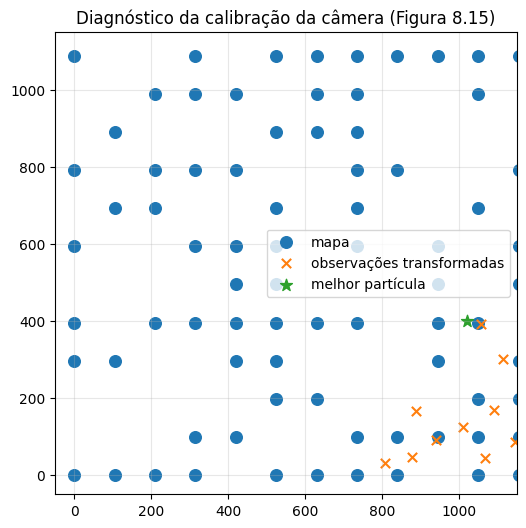

In [32]:
def transforma_obs_global(estado, obs):
    x, y, th = estado[:3]
    c, s = np.cos(th), np.sin(th)
    obs = np.asarray(obs, dtype=float).reshape((-1, 2))
    glob = np.empty_like(obs)
    glob[:, 0] = x + obs[:, 0] * c - obs[:, 1] * s
    glob[:, 1] = y + obs[:, 0] * s + obs[:, 1] * c
    return glob


def plota_diagnostico_camera(mapa, obs, melhor_estado):
    obs_global = transforma_obs_global(melhor_estado, obs)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect('equal')
    ax.scatter(mapa[:, 0], mapa[:, 1], s=70, label='mapa')
    ax.scatter(obs_global[:, 0], obs_global[:, 1], s=45, marker='x', label='observações transformadas')
    ax.scatter([melhor_estado[0]], [melhor_estado[1]], s=80, marker='*', label='melhor partícula')
    ax.set_xlim(-50, 1150)
    ax.set_ylim(-50, 1150)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_title('Diagnóstico da calibração da câmera (Figura 8.15)')
    plt.show()


if 'leituras' in globals() and mapa_configurado():
    rng = np.random.default_rng(3502)
    particulas, melhor_inicial, cam0, a_bias, w_bias, t_calib = localizacao_inicial(leituras, rng)
    plota_diagnostico_camera(MAPA_CIRCULOS, cam0.c, melhor_inicial)
else:
    print('Carregue a coleta e preenchá MAPA_CIRCULOS para rodar esta etapa.')


### Fase 3: reconstrução da trajetória

Depois da localização inicial, cada leitura de IMU executa previsão com `novo_estado`; cada leitura de câmera executa correção pelos pesos de `calc_w` e reamostragem. A cada passo guardamos a média das partículas para plotar a trajetória final.

In [40]:
from tqdm import tqdm
def corrige_por_camera(particulas, obs, mapa, rng):
    if len(obs) == 0:
        return particulas, np.nan
    w = pesos_camera(particulas, obs, mapa)
    eta = float(w.sum())
    if eta == 0.0:
        raise RuntimeError(
            'eta = 0 durante correção (robô perdido). Sinaliza o "sequestro" da '
            'seção 8.4.2: nenhuma partícula é compatível com a observação. Causas '
            'comuns: IMU ruidosa/ausente entre quadros, MAPA_CIRCULOS incorreto, ou '
            'coleta de IMU corrompida (vide aviso de le_coleta_csv).')
    idx = rng.choice(len(particulas), size=len(particulas), p=w / eta)
    return particulas[idx].copy(), eta


def reconstruir_trajetoria(leituras, rng=None):
    if not mapa_configurado():
        raise ValueError('Preencha MAPA_CIRCULOS antes de rodar a reconstrução.')
    if rng is None:
        rng = np.random.default_rng()

    particulas, melhor_inicial, cam0, a_bias, w_bias, t_calib = localizacao_inicial(leituras, rng)
    trajetoria = [media_particulas(particulas)]
    etas = []

    leituras_pos = [l for l in leituras if l.t >= cam0.t]
    ultimo_imu_t = None

    for leitura in tqdm(leituras_pos):
        if isinstance(leitura, IMUData):

            if ultimo_imu_t is None:
                ultimo_imu_t = leitura.t
                continue
            deltat = (leitura.t - ultimo_imu_t) / 1e9
            ultimo_imu_t = leitura.t
            if deltat <= 0:
                continue
            acao = acao_da_imu(leitura, a_bias, w_bias)
            particulas = np.array([
                novo_estado(p, acao, deltat, BETA_PRED, SIGMAX_PRED,
                            SIGMAY_PRED, SIGMAW_PRED, EPSILON_PRED)
                for p in particulas
            ])
            trajetoria.append(media_particulas(particulas))
        else:
            particulas, eta = corrige_por_camera(particulas, leitura.c, MAPA_CIRCULOS, rng)
            etas.append(eta)
            trajetoria.append(media_particulas(particulas))

    return np.asarray(trajetoria), particulas, np.asarray(etas)


if 'leituras' in globals() and mapa_configurado():
    rng = np.random.default_rng(3502)
    traj, particulas_finais, etas = reconstruir_trajetoria(leituras, rng)
    print('pontos na trajetória:', len(traj))
    print('correções por camera:', len(etas))
    if len(etas):
        print('eta min/med/max:', np.min(etas), np.mean(etas), np.max(etas))
else:
    print('Carregue a coleta e preenchá MAPA_CIRCULOS para rodar a reconstrução.')


oi


KeyboardInterrupt: 

In [25]:
if 'traj' in globals() and mapa_configurado():
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_aspect('equal')
    ax.scatter(MAPA_CIRCULOS[:, 0], MAPA_CIRCULOS[:, 1], s=70, label='círculos do mapa')
    ax.plot(traj[:, 0], traj[:, 1], '-k', linewidth=1.5, label='trajetória média')
    ax.scatter(traj[0, 0], traj[0, 1], marker='o', s=80, label='inicio')
    ax.scatter(traj[-1, 0], traj[-1, 1], marker='x', s=80, label='fim')
    ax.set_xlim(-50, 1150)
    ax.set_ylim(-50, 1150)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_title('Trajetória reconstruída (Figura 8.17)')
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    plt.show()

    if len(etas):
        plt.figure(figsize=(8, 3))
        plt.plot(etas)
        plt.title('Soma dos pesos nas correções por camera')
        plt.xlabel('índice da correção')
        plt.ylabel('eta')
        plt.grid(True, alpha=0.3)
        plt.show()
else:
    print('Rode a reconstrução antes de plotar.')


Rode a reconstrução antes de plotar.


### Checklist para depuração no robô

- Se `eta = 0` na localização inicial: confira `MAPA_CIRCULOS`, unidade das coordenadas do serviço de círculos e a calibração extrinseca da câmera.
- Se as observações transformadas ficam sistematicamente deslocadas no diagnóstico da Figura 8.15: refaça ou revise `camera_calibration_results.npz`.
- Se a trajetória anda na direção errada: revise `IMU_PARA_ROBO`.
- Se a trajetória explode mesmo com o robô parado: revise os ganhos `ACEL_GANHO_MM_S2_POR_CONTA` e `GIRO_GANHO_RAD_S_POR_CONTA`, e confirme que as primeiras 500 leituras foram coletadas com o robô completamente parado.
- Se há poucas correções por câmera: confira o FPS mostrado por `servico_circulos.py`, iluminação, foco e raio mínimo/máximo dos círculos.